# Gráficos de Cleveland: CT Congruentes vs Incongruentes por Categoría Ideológica

Este notebook genera **gráficos de Cleveland** para visualizar el Cambio de Tiempo (CT) comparando respuestas **congruentes** e **incongruentes** con la ideología, agrupadas por **categoría ideológica**.

## Concepto:

### Congruencia Ideológica:
- **CT_Congruente**: Ítems Progresistas → Izquierda + Ítems Conservadores → Derecha
- **CT_Incongruente**: Ítems Progresistas → Derecha + Ítems Conservadores → Izquierda

### Visualización:
- **Punto azul (●)**: CT Congruente (ideológicamente consistente)
- **Punto rojo (●)**: CT Incongruente (ideológicamente inconsistente)
- **Línea conectando**: Muestra la diferencia
- **Color de línea**:
  - Verde: Mayor CT en Incongruentes (>0.5s)
  - Gris: Similar (±0.5s)
  - Naranja: Mayor CT en Congruentes (<-0.5s)

## Interpretación:

- **Valores negativos**: Tiempos más rápidos (más negativos = menor tiempo de respuesta)
- **Hipótesis**: Se espera mayor tiempo (menos negativo) en ítems incongruentes (conflicto ideológico genera procesamiento más deliberado)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo.
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ Librerías cargadas exitosamente')

✓ Librerías cargadas exitosamente


## 1. Cargar Datos

In [2]:
# Rutas a los archivos.
Ruta_Base = os.path.join(os.getcwd(), '..', 'Data', 'Procesados')
Archivo_Generales = os.path.join(Ruta_Base, 
                                  'Generales_con_Congruencia.xlsx')
Archivo_Ballotage = os.path.join(Ruta_Base, 
                                  'Ballotage_con_Congruencia.xlsx')

# Cargar datos.
df_Generales = pd.read_excel(Archivo_Generales)
df_Ballotage = pd.read_excel(Archivo_Ballotage)

dfs = {
    'Generales': df_Generales,
    'Ballotage': df_Ballotage
}

print(f'✓ Datos cargados:')
print(f'  - Generales: {len(df_Generales)} registros')
print(f'  - Ballotage: {len(df_Ballotage)} registros')

# Verificar variables.
vars_necesarias = ['CT_Congruente', 'CT_Incongruente', 
                   'Categoria_PASO_2023']
for nombre, df in dfs.items():
    faltantes = [v for v in vars_necesarias if v not in df.columns]
    if faltantes:
        print(f'  ⚠️  {nombre}: Faltan variables {faltantes}')
    else:
        print(f'  ✅ {nombre}: Todas las variables presentes')

✓ Datos cargados:
  - Generales: 2786 registros
  - Ballotage: 1254 registros
  ✅ Generales: Todas las variables presentes
  ✅ Ballotage: Todas las variables presentes


## 2. Preparar Datos para Gráfico

In [3]:
# Definir categorías ideológicas.
Categorias = [
    'Left_Wing',
    'Progressivism',
    'Centre',
    'Moderate_Right_A',
    'Moderate_Right_B',
    'Right_Wing_Libertarian'
]

Etiquetas_Categorias = {
    'Left_Wing': 'Left Wing',
    'Progressivism': 'Progressivism',
    'Centre': 'Centre',
    'Moderate_Right_A': 'Moderate Right A',
    'Moderate_Right_B': 'Moderate Right B',
    'Right_Wing_Libertarian': 'Right Wing Libertarian'
}

print(f'Categorías ideológicas: {len(Categorias)}')
for cat in Categorias:
    print(f'  - {Etiquetas_Categorias[cat]}')

Categorías ideológicas: 6
  - Left Wing
  - Progressivism
  - Centre
  - Moderate Right A
  - Moderate Right B
  - Right Wing Libertarian


In [4]:
def Preparar_Datos_Por_Categoria(df, categorias):

    """
    Calcula promedios de CT_Congruente e Incongruente por categoría.
    Incluye test de Wilcoxon pareado para significancia estadística.

    """

    datos = []
    
    for categoria in categorias:
        df_cat = df[df['Categoria_PASO_2023'] == categoria]
        
        if len(df_cat) > 0:
            media_cong = df_cat['CT_Congruente'].mean()
            media_incong = df_cat['CT_Incongruente'].mean()
            diferencia = media_incong - media_cong
            
            # Test de Wilcoxon pareado para significancia.
            datos_pareados = df_cat[['CT_Congruente', 
                                     'CT_Incongruente']].dropna()
            if len(datos_pareados) > 1:
                from scipy.stats import wilcoxon
                try:
                    stat, p_valor = wilcoxon(
                        datos_pareados['CT_Incongruente'], 
                        datos_pareados['CT_Congruente']
                    )
                    
                    # Determinar asteriscos de significancia.
                    if p_valor < 0.001:
                        sig = '***'
                    elif p_valor < 0.01:
                        sig = '**'
                    elif p_valor < 0.05:
                        sig = '*'
                    else:
                        sig = ''
                except:
                    p_valor = np.nan
                    sig = ''
            else:
                p_valor = np.nan
                sig = ''
            
            datos.append({
                'Categoria': categoria,
                'Etiqueta': Etiquetas_Categorias[categoria],
                'n': len(df_cat),
                'CT_Congruente': media_cong,
                'CT_Incongruente': media_incong,
                'Diferencia': diferencia,
                'p_valor': p_valor,
                'Significancia': sig
            })
    
    return pd.DataFrame(datos)

# Preparar datos para ambos datasets.
datos_graficos = {}
for nombre, df in dfs.items():
    datos_graficos[nombre] = Preparar_Datos_Por_Categoria(
        df, 
        Categorias
    )
    print(f'\n{nombre}:')
    print(
        datos_graficos[nombre][[
            'Etiqueta', 'n', 'CT_Congruente', 'CT_Incongruente', 
            'Diferencia', 'Significancia'
        ]]
    )


Generales:
                 Etiqueta     n  CT_Congruente  CT_Incongruente  Diferencia  \
0               Left Wing   425      -2.286316        -2.110676    0.175641   
1           Progressivism  1257      -2.773036        -2.559977    0.213059   
2                  Centre    84      -2.955684        -2.738805    0.216878   
3        Moderate Right A   208      -3.180609        -3.100172    0.080436   
4        Moderate Right B   212      -2.680963        -2.802362   -0.121399   
5  Right Wing Libertarian   185      -3.684521        -3.167122    0.517399   

  Significancia  
0           ***  
1           ***  
2                
3                
4                
5            **  

Ballotage:
                 Etiqueta    n  CT_Congruente  CT_Incongruente  Diferencia  \
0               Left Wing  133      -2.424960        -2.522239   -0.097279   
1           Progressivism  597      -2.365716        -2.230339    0.135377   
2                  Centre   43      -3.115957        -3.597610

## 3. Función para Crear Gráfico de Cleveland

In [5]:
def Crear_Grafico_Cleveland_CT_Categorias(
    df, 
    titulo, 
    nombre_archivo = None, 
    carpeta_destino = 'Graficos_Cleveland'
):

    """
    Crea un gráfico de Cleveland mostrando CT Congruente vs 
    Incongruente por categoría.
    Incluye asteriscos para indicar significancia estadística.

    """

    # Crear carpeta si no existe.
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
    
    # Ordenar por diferencia (descendente).
    df_sorted = df.sort_values(
        'Diferencia', 
        ascending = True
    ).reset_index(drop = True)
    
    # Crear figura.
    fig, ax = plt.subplots(figsize = (12, 8))
    
    # Parámetros visuales.
    y_positions = np.arange(len(df_sorted))
    
    # Dibujar líneas conectando los puntos.
    for idx, row in df_sorted.iterrows():
        cong_val = row['CT_Congruente']
        incong_val = row['CT_Incongruente']
        diferencia = row['Diferencia']
        
        # Determinar color de línea según diferencia.
        if diferencia > 0.5:
            # Más CT en Incongruentes (menos negativo).
            color_linea = '#2ecc71'
            alpha = 0.7
        elif diferencia < -0.5:
            # Más CT en Congruentes (menos negativo).
            color_linea = '#e74c3c'
            alpha = 0.7
        else:
            # Diferencia pequeña.
            color_linea = '#95a5a6'
            alpha = 0.4
        
        # Dibujar línea.
        ax.plot(
            [cong_val, incong_val], 
            [idx, idx], 
            color = color_linea, 
            linewidth = 2, 
            alpha = alpha, 
            zorder = 1
        )
    
    # Dibujar puntos de Congruente.
    ax.scatter(
        df_sorted['CT_Congruente'], 
        y_positions, 
        s = 150, 
        c = '#3498db', 
        marker = 'o', 
        edgecolors = 'white', 
        linewidths = 2,
        label = 'Congruente', 
        zorder = 3, 
        alpha = 0.9
    )
    
    # Dibujar puntos de Incongruente.
    ax.scatter(
        df_sorted['CT_Incongruente'], 
        y_positions, 
        s = 150, 
        c = '#e74c3c', 
        marker = 'o', 
        edgecolors = 'white', 
        linewidths = 2,
        label = 'Incongruente', 
        zorder = 3, 
        alpha = 0.9
    )
    
    # Línea vertical en x = 0.
    ax.axvline(
        x = 0, 
        color = 'black', 
        linestyle = '--', 
        linewidth = 0.8, 
        alpha = 0.3, 
        zorder = 0
    )
    
    # Configurar ejes con asteriscos de significancia.
    ax.set_yticks(y_positions)
    etiquetas_con_sig = [
        f"{row['Etiqueta']} {row['Significancia']}" 
        if row['Significancia'] 
        else row['Etiqueta'] 
        for _, row in df_sorted.iterrows()
    ]
    ax.set_yticklabels(etiquetas_con_sig, fontsize = 11)
    
    ax.set_xlabel(
        'Cambio de Tiempo (promedio, segundos)', 
        fontsize = 12, 
        fontweight = 'bold'
    )
    ax.set_ylabel(
        'Categoría Ideológica', 
        fontsize = 12, 
        fontweight = 'bold'
    )
    ax.set_title(titulo, fontsize = 14, fontweight = 'bold', pad = 20)
    
    # Grid.
    ax.grid(
        True, 
        axis = 'x', 
        alpha = 0.3, 
        linestyle = ':', 
        linewidth = 0.5
    )
    ax.set_axisbelow(True)
    
    # Leyenda personalizada.
    legend_elements = [
        Line2D(
            [0], [0], 
            marker = 'o', 
            color = 'w', 
            markerfacecolor = '#3498db', 
            markersize = 11, 
            label = 'Congruente', 
            markeredgecolor = 'white', 
            markeredgewidth = 1.5
        ),
        Line2D(
            [0], [0], 
            marker = 'o', 
            color = 'w', 
            markerfacecolor = '#e74c3c', 
            markersize = 11, 
            label = 'Incongruente', 
            markeredgecolor = 'white', 
            markeredgewidth = 1.5
        ),
        Line2D(
            [0], [0], 
            color = '#2ecc71', 
            linewidth = 2.5, 
            label = 'Mayor Incong (>0.5s)'
        ),
        Line2D(
            [0], [0], 
            color = '#95a5a6', 
            linewidth = 2.5, 
            label = 'Similar (±0.5s)'
        ),
        Line2D(
            [0], [0], 
            color = '#e74c3c', 
            linewidth = 2.5, 
            label = 'Mayor Cong (<-0.5s)'
        ),
        Line2D(
            [0], [0], 
            marker = '', 
            color = 'w', 
            label = '* p<0.05, ** p<0.01, *** p<0.001'
        )
    ]
    
    ax.legend(
        handles = legend_elements, 
        loc = 'lower right', 
        fontsize = 10, 
        framealpha = 0.95, 
        edgecolor = 'gray'
    )
    
    # Ajustar layout.
    plt.tight_layout()
    
    # Guardar.
    if nombre_archivo:
        ruta_completa = os.path.join(
            carpeta_destino, 
            f'{nombre_archivo}.svg'
        )
        plt.savefig(
            ruta_completa.replace('.png', '.svg'), 
            format = 'svg', 
            bbox_inches = 'tight', 
            facecolor = 'white'
        )
        print(f'✅ Gráfico guardado: {ruta_completa}')
    
    plt.show()
    
    return fig, ax

## 4. Gráficos por Dataset

Generando gráfico para Generales...

✅ Gráfico guardado: Graficos_Cleveland\Cleveland_CT_Congruente_vs_Incongruente_Generales.svg


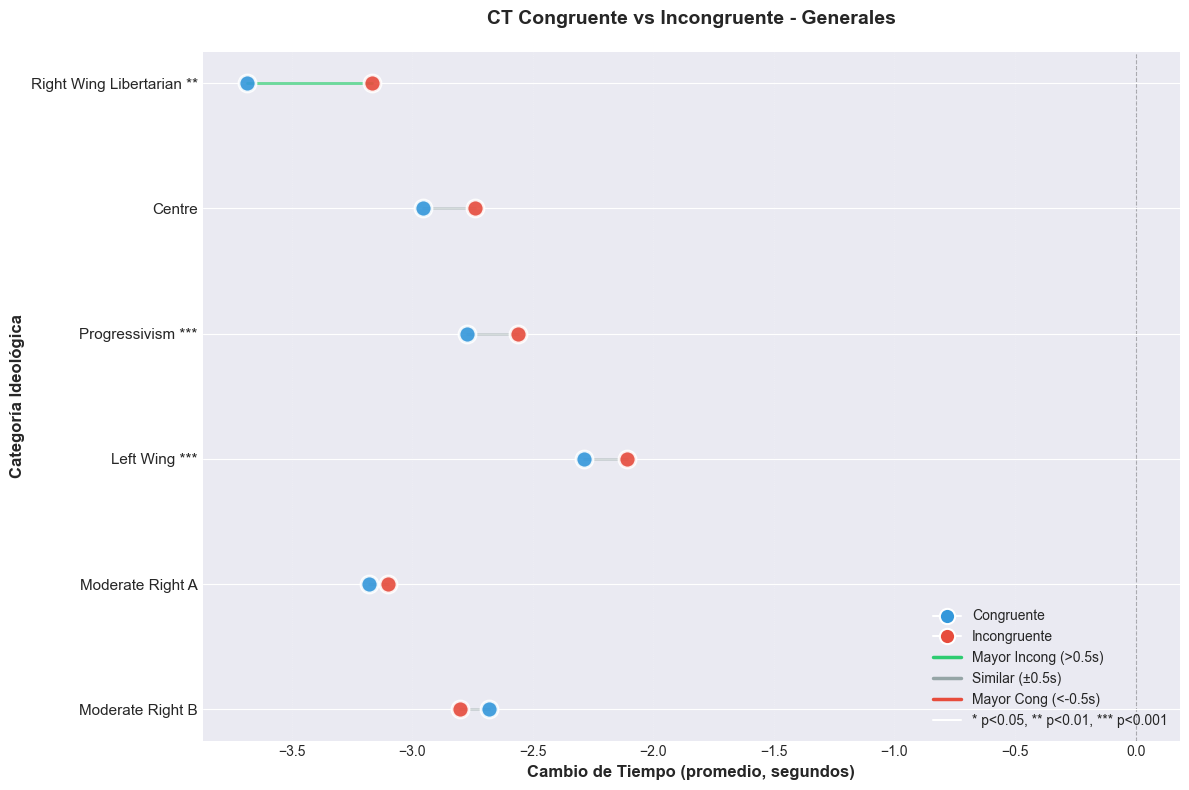

In [6]:
# Crear gráfico para Generales.
print('Generando gráfico para Generales...\n')
fig_gen, ax_gen = Crear_Grafico_Cleveland_CT_Categorias(
    datos_graficos['Generales'],
    titulo = 'CT Congruente vs Incongruente - Generales',
    nombre_archivo = (
        'Cleveland_CT_Congruente_vs_Incongruente_Generales'
    )
)

Generando gráfico para Ballotage...

✅ Gráfico guardado: Graficos_Cleveland\Cleveland_CT_Congruente_vs_Incongruente_Ballotage.svg


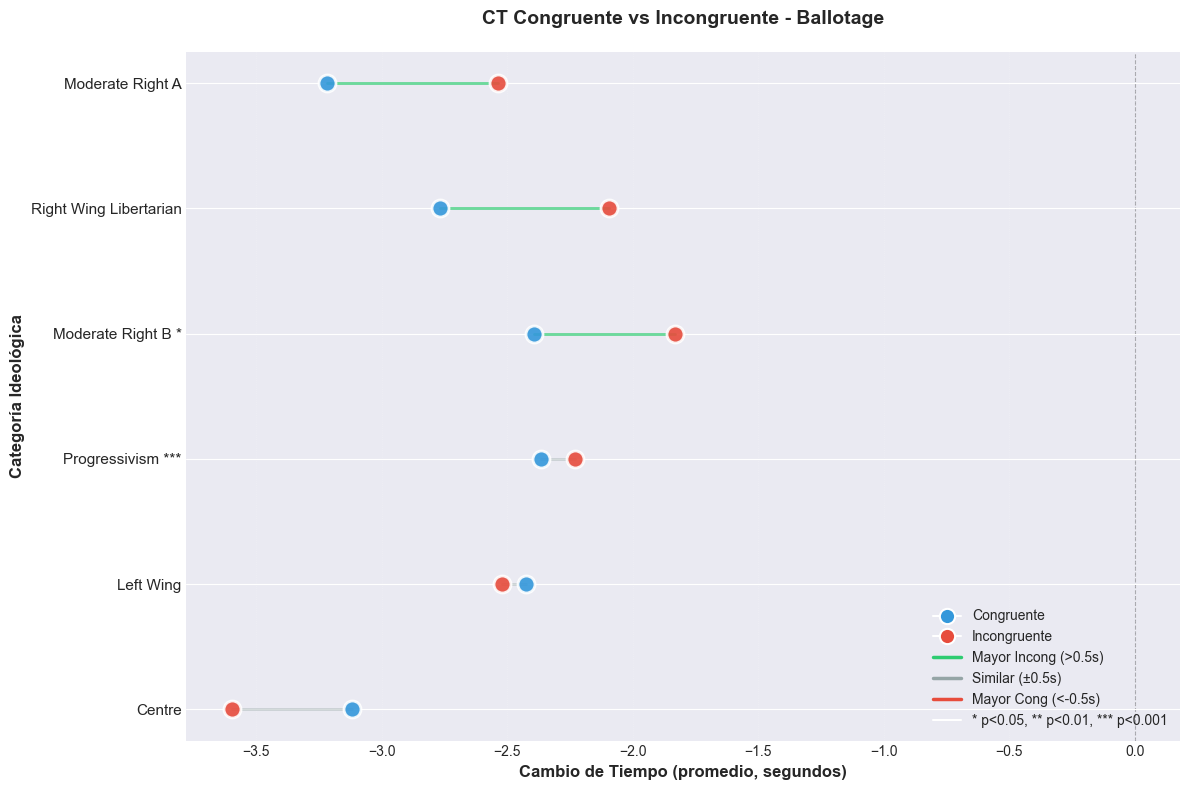

In [7]:
# Crear gráfico para Ballotage.
print('Generando gráfico para Ballotage...\n')
fig_bal, ax_bal = Crear_Grafico_Cleveland_CT_Categorias(
    datos_graficos['Ballotage'],
    titulo = 'CT Congruente vs Incongruente - Ballotage',
    nombre_archivo = (
        'Cleveland_CT_Congruente_vs_Incongruente_Ballotage'
    )
)

## 4.1. Análisis de Significancia Estadística

In [8]:
print('=' * 70)
print('ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA')
print('Test de Wilcoxon Pareado: CT Congruente vs Incongruente')
print('=' * 70)

for nombre, df_datos in datos_graficos.items():
    print(f'\n📊 {nombre}:')
    print('-' * 70)
    
    # Filtrar categorías con significancia.
    sig_categorias = df_datos[
        df_datos['Significancia'] != ''
    ].copy()
    
    if len(sig_categorias) > 0:
        print(
            f'\n✅ Categorías con diferencias significativas: '
            f'{len(sig_categorias)}'
        )
        print('\nDetalle:')
        for _, row in sig_categorias.iterrows():
            direccion = (
                'Incong > Cong' 
                if row['Diferencia'] > 0 
                else 'Cong > Incong'
            )
            print(
                f"  {row['Significancia']:3s} "
                f"{row['Etiqueta']:25s} | "
                f"Dif: {row['Diferencia']:6.3f}s | "
                f"p={row['p_valor']:.4f} | {direccion}"
            )
    else:
        print(
            '\n❌ No hay categorías con diferencias '
            'significativas (p < 0.05)'
        )
    
    # Categorías no significativas.
    no_sig = df_datos[df_datos['Significancia'] == '']
    if len(no_sig) > 0:
        print(
            f'\n⚪ Categorías sin diferencias '
            f'significativas: {len(no_sig)}'
        )
        for _, row in no_sig.iterrows():
            if not pd.isna(row['p_valor']):
                print(
                    f"      {row['Etiqueta']:25s} | "
                    f"Dif: {row['Diferencia']:6.3f}s | "
                    f"p={row['p_valor']:.4f}"
                )
    
    print('\n' + '-' * 70)

print('\n' + '=' * 70)
print('Niveles de significancia: * p<0.05, ** p<0.01, *** p<0.001')
print('=' * 70)

ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA
Test de Wilcoxon Pareado: CT Congruente vs Incongruente

📊 Generales:
----------------------------------------------------------------------

✅ Categorías con diferencias significativas: 3

Detalle:
  *** Left Wing                 | Dif:  0.176s | p=0.0000 | Incong > Cong
  *** Progressivism             | Dif:  0.213s | p=0.0000 | Incong > Cong
  **  Right Wing Libertarian    | Dif:  0.517s | p=0.0042 | Incong > Cong

⚪ Categorías sin diferencias significativas: 3
      Centre                    | Dif:  0.217s | p=0.3135
      Moderate Right A          | Dif:  0.080s | p=0.7239
      Moderate Right B          | Dif: -0.121s | p=0.0928

----------------------------------------------------------------------

📊 Ballotage:
----------------------------------------------------------------------

✅ Categorías con diferencias significativas: 2

Detalle:
  *** Progressivism             | Dif:  0.135s | p=0.0008 | Incong > Cong
  *   Moderate Right B        

## 4.2. Comparaciones Entre Poblaciones (Test Post-Hoc)

**NUEVO**: Análisis de diferencias significativas **entre las 6 categorías ideológicas** usando el test de Dunn con corrección de Bonferroni.

Este análisis responde: ¿Existen diferencias significativas entre Left Wing y Progressivism? ¿Entre Moderate Right A y Moderate Right B? Etc.

In [ ]:
# Instalar si es necesario: pip install scikit-posthocs
import scikit_posthocs as sp
from scipy.stats import kruskal

def Analizar_Diferencias_Entre_Poblaciones(df, variable, nombre_dataset):

    """
    Realiza test de Kruskal-Wallis seguido de test post-hoc de Dunn
    para comparar diferencias entre categorías ideológicas.

    """

    print(f'\n{"="*70}')
    print(f'COMPARACIONES ENTRE POBLACIONES: {variable} - {nombre_dataset}')
    print(f'{"="*70}')

    # Preparar datos por categoría
    Grupos = []
    Categorias_Con_Datos = []

    for cat in Categorias:
        datos_cat = df[df['Categoria_PASO_2023'] == cat][variable].dropna()
        if len(datos_cat) > 0:
            Grupos.append(datos_cat)
            Categorias_Con_Datos.append(cat)

    # Test de Kruskal-Wallis
    if len(Grupos) < 2:
        print('⚠️  No hay suficientes grupos para comparar')
        return None, []

    H_stat, p_kruskal = kruskal(*Grupos)

    print(f'\nTest de Kruskal-Wallis:')
    print(f'  Estadístico H: {H_stat:.4f}')
    print(f'  p-valor: {p_kruskal:.6f}')

    if p_kruskal >= 0.05:
        print(f'  ❌ NO SIGNIFICATIVO (p ≥ 0.05)')
        print(f'     No hay diferencias significativas entre poblaciones')
        return None, []

    print(f'  ✅ SIGNIFICATIVO (p < 0.05)')
    print(f'     Existen diferencias significativas entre poblaciones')

    # Test post-hoc de Dunn con corrección de Bonferroni
    print(f'\nTest Post-Hoc de Dunn (corrección de Bonferroni):')

    # Preparar DataFrame para el test
    df_test = df[df['Categoria_PASO_2023'].isin(Categorias_Con_Datos)].copy()
    df_test = df_test[['Categoria_PASO_2023', variable]].dropna()

    # Ejecutar test de Dunn
    Matriz_Pvalores = sp.posthoc_dunn(
        df_test,
        val_col=variable,
        group_col='Categoria_PASO_2023',
        p_adjust='bonferroni'
    )

    # Renombrar índices y columnas con etiquetas legibles
    Mapeo_Etiquetas = {
        cat: Etiquetas_Categorias[cat]
        for cat in Categorias_Con_Datos
    }
    Matriz_Pvalores.index = Matriz_Pvalores.index.map(Mapeo_Etiquetas)
    Matriz_Pvalores.columns = Matriz_Pvalores.columns.map(Mapeo_Etiquetas)

    # Mostrar comparaciones significativas
    print(f'\nComparaciones significativas (p < 0.05):')

    Comparaciones_Sig = []
    for i in range(len(Matriz_Pvalores)):
        for j in range(i+1, len(Matriz_Pvalores)):
            p_val = Matriz_Pvalores.iloc[i, j]
            if p_val < 0.05:
                cat1 = Matriz_Pvalores.index[i]
                cat2 = Matriz_Pvalores.index[j]

                # Determinar asteriscos
                if p_val < 0.001:
                    sig = '***'
                elif p_val < 0.01:
                    sig = '**'
                else:
                    sig = '*'

                Comparaciones_Sig.append((cat1, cat2, p_val, sig))
                print(
                    f'  {sig:3s} {cat1:25s} vs {cat2:25s} | '
                    f'p={p_val:.4f}'
                )

    if len(Comparaciones_Sig) == 0:
        print(f'  ⚪ No hay comparaciones significativas después de corrección')

    return Matriz_Pvalores, Comparaciones_Sig


# Análisis para ambos datasets y ambas variables
Resultados_Comparaciones = {}

for nombre_ds in ['Generales', 'Ballotage']:
    Resultados_Comparaciones[nombre_ds] = {}

    for variable in ['CT_Congruente', 'CT_Incongruente']:
        matriz, comp = Analizar_Diferencias_Entre_Poblaciones(
            dfs[nombre_ds],
            variable,
            nombre_ds
        )
        Resultados_Comparaciones[nombre_ds][variable] = (matriz, comp)

print(f'\n{"="*70}')
print(f'ANÁLISIS DE COMPARACIONES COMPLETADO')
print(f'{"="*70}')

## 4.3. Matrices de Significancia

Visualización en forma de heatmap de los p-valores de todas las comparaciones por pares.

In [ ]:
def Crear_Matriz_Significancia(matriz_pvalores, titulo, nombre_archivo=None):

    """
    Crea un heatmap de la matriz de p-valores de comparaciones por pares.

    """

    if matriz_pvalores is None:
        print(f'⚠️  No hay datos de comparaciones para {titulo}')
        return None

    mask = np.triu(np.ones_like(matriz_pvalores, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        matriz_pvalores,
        mask=mask,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',
        vmin=0,
        vmax=0.1,
        cbar_kws={'label': 'p-valor'},
        square=True,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()

    if nombre_archivo:
        ruta = os.path.join('Graficos_Cleveland', f'{nombre_archivo}.svg')
        plt.savefig(
            ruta,
            format='svg',
            bbox_inches='tight',
            facecolor='white'
        )
        print(f'Matriz guardada: {ruta}')

    plt.show()

    return fig, ax


# Generar matrices para cada dataset y variable
print(f'\n{"="*70}')
print(f'MATRICES DE SIGNIFICANCIA (p-valores de comparaciones por pares)')
print(f'{"="*70}\n')

for nombre_ds in ['Generales', 'Ballotage']:
    for variable in ['CT_Congruente', 'CT_Incongruente']:
        matriz, _ = Resultados_Comparaciones[nombre_ds][variable]

        if matriz is not None:
            titulo = f'Matriz de p-valores: {variable} - {nombre_ds}'
            nombre_archivo = f'Matriz_{variable}_{nombre_ds}'.replace(' ', '_')

            Crear_Matriz_Significancia(matriz, titulo, nombre_archivo)

print(f'\n{"="*70}')
print(f'Verde = p-valor bajo (significativo)')
print(f'Rojo = p-valor alto (no significativo)')
print(f'{"="*70}')

## 4.4. Gráficos Cleveland con Comparaciones Entre Poblaciones

Regeneramos los gráficos Cleveland incluyendo **corchetes en el margen derecho** que muestran qué poblaciones tienen diferencias significativas entre sí.

- **Corchetes azules**: Diferencias significativas en CT_Congruente
- **Corchetes rojos**: Diferencias significativas en CT_Incongruente

In [ ]:
def Crear_Cleveland_Con_Comparaciones(
    df,
    titulo,
    comparaciones_sig_cong=None,
    comparaciones_sig_incong=None,
    nombre_archivo=None,
    carpeta_destino='Graficos_Cleveland'
):

    """
    Crea gráfico de Cleveland con corchetes mostrando comparaciones
    significativas entre poblaciones.
    Los corchetes azules indican diferencias en CT_Congruente.
    Los corchetes rojos indican diferencias en CT_Incongruente.

    """

    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)

    df_sorted = df.sort_values(
        'Diferencia',
        ascending=True
    ).reset_index(drop=True)

    # Crear figura con espacio adicional si hay comparaciones
    tiene_comparaciones = (
        (comparaciones_sig_cong and len(comparaciones_sig_cong) > 0)
        or
        (comparaciones_sig_incong and len(comparaciones_sig_incong) > 0)
    )
    ancho = 16 if tiene_comparaciones else 12
    fig, ax = plt.subplots(figsize=(ancho, 10))

    y_positions = np.arange(len(df_sorted))

    # Dibujar líneas y puntos
    for idx, row in df_sorted.iterrows():
        cong_val = row['CT_Congruente']
        incong_val = row['CT_Incongruente']
        diferencia = row['Diferencia']

        if diferencia > 0.5:
            color_linea = '#2ecc71'
            alpha = 0.7
        elif diferencia < -0.5:
            color_linea = '#e74c3c'
            alpha = 0.7
        else:
            color_linea = '#95a5a6'
            alpha = 0.4

        ax.plot(
            [cong_val, incong_val],
            [idx, idx],
            color=color_linea,
            linewidth=2,
            alpha=alpha,
            zorder=1
        )

    ax.scatter(
        df_sorted['CT_Congruente'],
        y_positions,
        s=150,
        c='#3498db',
        marker='o',
        edgecolors='white',
        linewidths=2,
        label='Congruente',
        zorder=3,
        alpha=0.9
    )

    ax.scatter(
        df_sorted['CT_Incongruente'],
        y_positions,
        s=150,
        c='#e74c3c',
        marker='o',
        edgecolors='white',
        linewidths=2,
        label='Incongruente',
        zorder=3,
        alpha=0.9
    )

    ax.axvline(
        x=0,
        color='black',
        linestyle='--',
        linewidth=0.8,
        alpha=0.3,
        zorder=0
    )

    # Configurar ejes
    ax.set_yticks(y_positions)
    etiquetas_con_sig = [
        f"{row['Etiqueta']} {row['Significancia']}"
        if row['Significancia'] else row['Etiqueta']
        for _, row in df_sorted.iterrows()
    ]
    ax.set_yticklabels(etiquetas_con_sig, fontsize=11)

    ax.set_xlabel(
        'Cambio de Tiempo (promedio, segundos)',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_ylabel(
        'Categoría Ideológica',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20)

    ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)

    # Mapear etiquetas a posiciones Y
    etiqueta_a_pos = {
        row['Etiqueta']: idx
        for idx, row in df_sorted.iterrows()
    }

    xlims = ax.get_xlim()
    rango_x = xlims[1] - xlims[0]
    x_bracket_base = xlims[1] + rango_x * 0.08

    contador_corchetes = 0

    # Dibujar corchetes AZULES para CT_Congruente
    if comparaciones_sig_cong and len(comparaciones_sig_cong) > 0:
        for cat1, cat2, p_val, sig in comparaciones_sig_cong[:5]:
            if cat1 in etiqueta_a_pos and cat2 in etiqueta_a_pos:
                y1 = etiqueta_a_pos[cat1]
                y2 = etiqueta_a_pos[cat2]
                y_min = min(y1, y2)
                y_max = max(y1, y2)

                x_pos = x_bracket_base + contador_corchetes * rango_x * 0.05
                contador_corchetes += 1

                color = '#3498db'

                ax.plot(
                    [x_pos, x_pos],
                    [y_min, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                tick_len = rango_x * 0.015
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_max, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_min, y_min],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                ax.text(
                    x_pos + tick_len * 1.5,
                    (y_min + y_max) / 2,
                    sig,
                    fontsize=10,
                    va='center',
                    color=color,
                    fontweight='bold',
                    clip_on=False
                )

    # Dibujar corchetes ROJOS para CT_Incongruente
    if comparaciones_sig_incong and len(comparaciones_sig_incong) > 0:
        for cat1, cat2, p_val, sig in comparaciones_sig_incong[:5]:
            if cat1 in etiqueta_a_pos and cat2 in etiqueta_a_pos:
                y1 = etiqueta_a_pos[cat1]
                y2 = etiqueta_a_pos[cat2]
                y_min = min(y1, y2)
                y_max = max(y1, y2)

                x_pos = x_bracket_base + contador_corchetes * rango_x * 0.05
                contador_corchetes += 1

                color = '#e74c3c'

                ax.plot(
                    [x_pos, x_pos],
                    [y_min, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                tick_len = rango_x * 0.015
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_max, y_max],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )
                ax.plot(
                    [x_pos, x_pos + tick_len],
                    [y_min, y_min],
                    color=color,
                    linewidth=2.5,
                    clip_on=False,
                    zorder=10
                )

                ax.text(
                    x_pos + tick_len * 1.5,
                    (y_min + y_max) / 2,
                    sig,
                    fontsize=10,
                    va='center',
                    color=color,
                    fontweight='bold',
                    clip_on=False
                )

    # Leyenda simplificada
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='#3498db',
            markersize=11,
            label='Congruente',
            markeredgecolor='white',
            markeredgewidth=1.5
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='#e74c3c',
            markersize=11,
            label='Incongruente',
            markeredgecolor='white',
            markeredgewidth=1.5
        ),
        Line2D(
            [0], [0],
            color='#2ecc71',
            linewidth=2.5,
            label='Mayor Incong (>0.5s)'
        ),
        Line2D(
            [0], [0],
            color='#95a5a6',
            linewidth=2.5,
            label='Similar (±0.5s)'
        ),
        Line2D(
            [0], [0],
            color='#e74c3c',
            linewidth=2.5,
            label='Mayor Cong (<-0.5s)'
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        framealpha=0.95,
        edgecolor='gray'
    )

    plt.tight_layout()

    if nombre_archivo:
        ruta_completa = os.path.join(
            carpeta_destino,
            f'{nombre_archivo}.svg'
        )
        plt.savefig(
            ruta_completa,
            format='svg',
            bbox_inches='tight',
            facecolor='white'
        )
        print(f'Grafico guardado: {ruta_completa}')

    plt.show()

    return fig, ax


# Generar graficos
print('='*70)
print('GRAFICOS CLEVELAND CON COMPARACIONES ENTRE POBLACIONES')
print('='*70)

for nombre_ds in ['Generales', 'Ballotage']:
    print(f'\n{nombre_ds}:')
    print('-'*70)

    # Obtener comparaciones para ambas variables
    _, comp_sig_cong = Resultados_Comparaciones[nombre_ds].get(
        'CT_Congruente',
        (None, [])
    )
    _, comp_sig_incong = Resultados_Comparaciones[nombre_ds].get(
        'CT_Incongruente',
        (None, [])
    )

    if len(comp_sig_cong) > 0:
        print(
            f'  {len(comp_sig_cong)} comparaciones '
            f'significativas detectadas (CT_Congruente)'
        )
        for cat1, cat2, p, sig in comp_sig_cong[:5]:
            print(f'    {sig} {cat1} vs {cat2} (p={p:.4f})')

    if len(comp_sig_incong) > 0:
        print(
            f'  {len(comp_sig_incong)} comparaciones '
            f'significativas detectadas (CT_Incongruente)'
        )
        for cat1, cat2, p, sig in comp_sig_incong[:5]:
            print(f'    {sig} {cat1} vs {cat2} (p={p:.4f})')

    if len(comp_sig_cong) == 0 and len(comp_sig_incong) == 0:
        print(f'  No hay comparaciones significativas entre poblaciones')

    print(f'\n  Generando grafico...')

    fig, ax = Crear_Cleveland_Con_Comparaciones(
        datos_graficos[nombre_ds],
        titulo=(
            f'CT Congruente vs Incongruente - {nombre_ds}\n'
            f'(con comparaciones entre poblaciones)'
        ),
        comparaciones_sig_cong=comp_sig_cong,
        comparaciones_sig_incong=comp_sig_incong,
        nombre_archivo=f'Cleveland_CT_ConComparaciones_{nombre_ds}'
    )

print('\n' + '='*70)
print('GRAFICOS COMPLETADOS')
print('='*70)


## 5. Análisis Estadístico

In [9]:
print('=' * 70)
print('ANÁLISIS ESTADÍSTICO: CT CONGRUENTE VS INCONGRUENTE')
print('=' * 70)

for nombre, df_datos in datos_graficos.items():
    print(f'\n📊 {nombre}:')
    print('-' * 70)
    
    print(f'\nEstadísticas Generales:')
    print(
        f'  Promedio CT_Congruente: '
        f'{df_datos["CT_Congruente"].mean():.4f}s'
    )
    print(
        f'  Promedio CT_Incongruente: '
        f'{df_datos["CT_Incongruente"].mean():.4f}s'
    )
    print(
        f'  Diferencia promedio: '
        f'{df_datos["Diferencia"].mean():.4f}s'
    )
    
    # Distribución.
    mayor_incong = len(
        df_datos[df_datos['Diferencia'] > 0.5]
    )
    similares = len(
        df_datos[
            (df_datos['Diferencia'] >= -0.5) & 
            (df_datos['Diferencia'] <= 0.5)
        ]
    )
    mayor_cong = len(
        df_datos[df_datos['Diferencia'] < -0.5]
    )
    
    print(f'\nDistribución:')
    print(f'  Mayor en Incongruentes: {mayor_incong} categorías')
    print(f'  Similar: {similares} categorías')
    print(f'  Mayor en Congruentes: {mayor_cong} categorías')
    
    # Test t pareado.
    t_stat, p_value = stats.ttest_rel(
        df_datos['CT_Incongruente'], 
        df_datos['CT_Congruente']
    )
    
    print(f'\nTest t Pareado:')
    print(f'  Estadístico t: {t_stat:.4f}')
    print(f'  Valor p: {p_value:.4f}')
    
    if p_value < 0.05:
        print(f'  ✅ SIGNIFICATIVO (p < 0.05)')
        if df_datos['Diferencia'].mean() > 0:
            print(f'     Mayor CT en Incongruentes')
        else:
            print(f'     Mayor CT en Congruentes')
    else:
        print(f'  ❌ NO SIGNIFICATIVO (p ≥ 0.05)')
    
    print('\n' + '-' * 70)

print('\n' + '=' * 70)

ANÁLISIS ESTADÍSTICO: CT CONGRUENTE VS INCONGRUENTE

📊 Generales:
----------------------------------------------------------------------

Estadísticas Generales:
  Promedio CT_Congruente: -2.9269s
  Promedio CT_Incongruente: -2.7465s
  Diferencia promedio: 0.1803s

Distribución:
  Mayor en Incongruentes: 1 categorías
  Similar: 5 categorías
  Mayor en Congruentes: 0 categorías

Test t Pareado:
  Estadístico t: 2.1201
  Valor p: 0.0875
  ❌ NO SIGNIFICATIVO (p ≥ 0.05)

----------------------------------------------------------------------

📊 Ballotage:
----------------------------------------------------------------------

Estadísticas Generales:
  Promedio CT_Congruente: -2.7145s
  Promedio CT_Incongruente: -2.4691s
  Diferencia promedio: 0.2454s

Distribución:
  Mayor en Incongruentes: 3 categorías
  Similar: 3 categorías
  Mayor en Congruentes: 0 categorías

Test t Pareado:
  Estadístico t: 1.2639
  Valor p: 0.2620
  ❌ NO SIGNIFICATIVO (p ≥ 0.05)

-------------------------------------

## 6. Categorías con Mayor Diferencia

In [10]:
print('=' * 70)
print('CATEGORÍAS CON MAYOR DIFERENCIA')
print('=' * 70)

for nombre, df_datos in datos_graficos.items():
    print(f'\n📊 {nombre}:')
    print('-' * 70)
    
    print(f'\nMayor diferencia (Incong > Cong):')
    top_incong = df_datos.nlargest(3, 'Diferencia')[[
        'Etiqueta', 'CT_Congruente', 'CT_Incongruente', 'Diferencia'
    ]]
    print(top_incong.to_string(index = False))
    
    print(f'\nMayor diferencia (Cong > Incong):')
    top_cong = df_datos.nsmallest(3, 'Diferencia')[[
        'Etiqueta', 'CT_Congruente', 'CT_Incongruente', 'Diferencia'
    ]]
    print(top_cong.to_string(index = False))
    
    print('\n' + '-' * 70)

print('\n' + '=' * 70)

CATEGORÍAS CON MAYOR DIFERENCIA

📊 Generales:
----------------------------------------------------------------------

Mayor diferencia (Incong > Cong):
              Etiqueta  CT_Congruente  CT_Incongruente  Diferencia
Right Wing Libertarian      -3.684521        -3.167122    0.517399
                Centre      -2.955684        -2.738805    0.216878
         Progressivism      -2.773036        -2.559977    0.213059

Mayor diferencia (Cong > Incong):
        Etiqueta  CT_Congruente  CT_Incongruente  Diferencia
Moderate Right B      -2.680963        -2.802362   -0.121399
Moderate Right A      -3.180609        -3.100172    0.080436
       Left Wing      -2.286316        -2.110676    0.175641

----------------------------------------------------------------------

📊 Ballotage:
----------------------------------------------------------------------

Mayor diferencia (Incong > Cong):
              Etiqueta  CT_Congruente  CT_Incongruente  Diferencia
      Moderate Right A      -3.217902     

## 7. Guardar Tablas Resumen

In [11]:
# Crear carpeta de salida.
Carpeta_Salida = os.path.join(
    os.getcwd(), 
    '..', 
    'Data', 
    'Resultados_Cleveland'
)
if not os.path.exists(Carpeta_Salida):
    os.makedirs(Carpeta_Salida)

# Guardar tablas.
for nombre, df_datos in datos_graficos.items():
    archivo = os.path.join(
        Carpeta_Salida, 
        f'Resumen_CT_Congruente_vs_Incongruente_{nombre}.xlsx'
    )
    df_datos.to_excel(archivo, index = False)
    print(f'✅ Guardado: {archivo}')

✅ Guardado: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Código\..\Data\Resultados_Cleveland\Resumen_CT_Congruente_vs_Incongruente_Generales.xlsx
✅ Guardado: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Código\..\Data\Resultados_Cleveland\Resumen_CT_Congruente_vs_Incongruente_Ballotage.xlsx


## 8. Resumen Final

In [12]:
print('=' * 70)
print('RESUMEN: CT CONGRUENTE VS INCONGRUENTE POR CATEGORÍA')
print('=' * 70)

print('\n📊 Análisis completado:')
print(f'  - Datasets analizados: 2 (Generales y Ballotage)')
print(f'  - Categorías por dataset: {len(Categorias)}')
print(f'  - Gráficos generados: 2 (Cleveland plots)')

print('\n📁 Archivos generados:')
print('  - Cleveland_CT_Congruente_vs_Incongruente_Generales.svg')
print('  - Cleveland_CT_Congruente_vs_Incongruente_Ballotage.svg')
print(
    '  - Resumen_CT_Congruente_vs_Incongruente_Generales.xlsx'
)
print(
    '  - Resumen_CT_Congruente_vs_Incongruente_Ballotage.xlsx'
)

print('\n💡 Interpretación:')
print('  - CT_Congruente: Tiempo en cambios ideológicamente '
      'consistentes')
print('  - CT_Incongruente: Tiempo en cambios ideológicamente '
      'inconsistentes')
print('  - Hipótesis: Mayor tiempo (menos negativo) en '
      'incongruentes')
print('    (conflicto ideológico genera procesamiento más '
      'deliberado)')

print('\n' + '=' * 70)
print('✅ ANÁLISIS COMPLETADO')
print('=' * 70)

RESUMEN: CT CONGRUENTE VS INCONGRUENTE POR CATEGORÍA

📊 Análisis completado:
  - Datasets analizados: 2 (Generales y Ballotage)
  - Categorías por dataset: 6
  - Gráficos generados: 2 (Cleveland plots)

📁 Archivos generados:
  - Cleveland_CT_Congruente_vs_Incongruente_Generales.svg
  - Cleveland_CT_Congruente_vs_Incongruente_Ballotage.svg
  - Resumen_CT_Congruente_vs_Incongruente_Generales.xlsx
  - Resumen_CT_Congruente_vs_Incongruente_Ballotage.xlsx

💡 Interpretación:
  - CT_Congruente: Tiempo en cambios ideológicamente consistentes
  - CT_Incongruente: Tiempo en cambios ideológicamente inconsistentes
  - Hipótesis: Mayor tiempo (menos negativo) en incongruentes
    (conflicto ideológico genera procesamiento más deliberado)

✅ ANÁLISIS COMPLETADO
